# **UCI HAR - CNN + GRU Classification**
- 모델 구조 참고 논문 : A_Multichannel_CNN-GRU_Model_for_Human_Activity_Recognition
  - Layer : MultiChannel CNN 3개(3x3, 5x5, 7x7) + GRU 2개 + Dense 1개



---

# **Single Path vs MultiChannel CNN**
  - Single Path
    - 방식 : 직렬연결 (단일경로)
    - 비유 : 고속도로에서 차가 터널을 '하나씩 차례대로' 통과하는 것
    - 과정 : 입력 데이터가 Layer 1을 지나고, 그 결과가 다시 Layer 2로 들어가는 순차적인 과정
    - Single Path의 근본적 한계
      - 정보의 간섭 : '이전 층에서 뽑아놓은 특징'을 '다음 층의 필터'가 강제로 받아들여야 함.
      - 필터 사이즈가 커져도 초기 정보가 이미 국소적(Local)으로 갇혀버리는 문제가 발생.
      - 다양한 관점의 특징들을 모두 살리지 못 하고, 차례대로 가공되며 정보를 잃거나 변형됨. (다양한 시간적·공간적 특징 추출에 한계)
  - MultiChannel CNN
    - 방식 : 병렬연결
    - 비유 : 갈림길이 있는 '고속도로 톨게이트'
    - 과정
      1. 데이터가 입구에서 똑같이 복사되어 여러 갈래의 길(채널)로 동시에 들어감.
      2. 각 채널은 서로 다른 조건(논문에서는 서로 다른 커널 사이즈)을 갖고 있음.
      3. 각 채널을 통과한 데이터들은 각기 다른 특징을 추출.
      4. 마지막에 Concatenation 층에서 이 정보들을 모두 연결시켜 하나의 데이터로 출력.
    - Single Path 대신 MultiChannel을 사용하는 이유
      - 입력 원본 데이터를 서로 다른 필터들이 각자 '독립적'으로 '동시에' 관찰 > 정보의 입체감이 살아남.
      - 각 필터 사이즈별로 더 깊은 학습(더 자세하고 순도 높은 특징 추출)이 가능 > 다양한 스케일의 특징을 효과적으로 추출 가능.
      - 마지막에 이 정보들을 합침으로써, '아주 자세한 특징 + 큼직한 흐름'을 모두 가진 입체적인 모델 설계 가능.

# **LSTM vs GRU**
- 이 논문에서는 왜 GRU 구조를 택했을까?
  - 궁극적으로는 "불필요한 복잡함을 걷어내고, 정확도는 지키면서 연산 속도는 높이는, [성능은 유지하면서, 효율성을 극대화] 하기 위해"
  1. 연산 효율성과 속도
      - 스마트폰 센서 데이터나 라즈베리 파이와 같은 'Edge Device'에서 실시간 동작 인식을 수행하려면 모델이 가벼워야 함.
      - 구조적 단순함: LSTM은 3개의 게이트(Forget, Input, Output)를 관리해야 하지만, GRU는 2개의 게이트(Update, Reset)만 사용.
      - 파라미터 개수: GRU는 파라미터 수가 적어 모델이 가볍고, 연산 횟수가 적음. (즉, 실시간 처리 시 지연 시간을 줄이는 데 결정적)
  2. 센서 데이터의 특성
      - 센서 데이터(가속도, 자이로스코프 등)는 상대적으로 패턴이 단순하고 데이터의 '시계열 의존성'이 아주 길지 않은 편.
      - LSTM은 매우 '긴 문맥(오래전 기억)'을 보존하는 데 최적화되어 있음.
      - 센서 데이터는 짧은 윈도우(Time Window) 내에서 발생하는 즉각적인 패턴이 중요.
      - So, 굳이 복잡한 LSTM을 쓸 필요가 없다고 판단.
  3. 과적합(Overfitting) 방지
      - 데이터셋 규모가 크지 않은 센서 데이터는 모델이 너무 복잡하면 쉽게 과적합이 발생.
      - 데이터의 일반적인 특징을 비교적 더 간결하게 학습하는 경향 = 새로운 사람의 동작 데이터에 대해서도 더 유연하게 대처(일반화) 가능.



---



In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input, Model, backend as K
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Conv1D, BatchNormalization, ReLU, MaxPooling1D, GlobalAveragePooling1D, GRU, Concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
INPUT_SIGNAL_TYPES = [
    "body_acc_x_",
    "body_acc_y_",
    "body_acc_z_",
    "body_gyro_x_",
    "body_gyro_y_",
    "body_gyro_z_",
    "total_acc_x_",
    "total_acc_y_",
    "total_acc_z_"
]

LABELS = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

In [3]:
TRAIN = "train/"
TEST = "test/"

DATASET_PATH = "/content/drive/MyDrive/AI_assignment/UCI_HAR_Dataset/"

In [52]:
# Load "X"
def load_X(X_signals_paths):
    X_signals = []

    for signal_type_path in X_signals_paths:
        series_list = []                                        # 한 센서축 데이터 전체 저장

        with open(signal_type_path, 'r') as file:
            for row in file:
                row_clean = row.replace('  ', ' ')              # 공백 2개를 1개로
                row_clean = row_clean.strip()                   # 양쪽 공백 제거
                serie = row_clean.split(' ')                    # 공백 기준 split
                serie_array = np.array(serie, dtype=np.float32) # float32 numpy 배열로 변환
                series_list.append(serie_array)                 # 시퀀스 추가

        # 하나의 센서축 데이터 추가 (feature)
        X_signals.append(series_list)

    # shape: (특성 수, 샘플 수, 타임스텝 수)
    X_signals = np.array(X_signals)
    # shape 변환 → (샘플 수, 타임스텝 수, 특성 수)
    return np.transpose(X_signals, (1, 2, 0))


X_train_signals_paths = [
    DATASET_PATH + TRAIN + "Inertial_Signals/" + signal + "train.txt"
    for signal in INPUT_SIGNAL_TYPES
]
X_test_signals_paths = [
    DATASET_PATH + TEST + "Inertial_Signals/" + signal + "test.txt"
    for signal in INPUT_SIGNAL_TYPES
]

X_train = load_X(X_train_signals_paths)
X_test = load_X(X_test_signals_paths)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("첫 번째 샘플 데이터:\n", X_train[0])

X_train shape: (7352, 128, 9)
X_test shape: (2947, 128, 9)
첫 번째 샘플 데이터:
 [[ 1.808515e-04  1.076681e-02  5.556068e-02 ...  1.012817e+00
  -1.232167e-01  1.029341e-01]
 [ 1.013856e-02  6.579480e-03  5.512483e-02 ...  1.022833e+00
  -1.268756e-01  1.056872e-01]
 [ 9.275574e-03  8.928878e-03  4.840473e-02 ...  1.022028e+00
  -1.240037e-01  1.021025e-01]
 ...
 [-1.147484e-03  1.714439e-04  2.647864e-03 ...  1.018445e+00
  -1.240696e-01  1.003852e-01]
 [-2.222655e-04  1.574181e-03  2.381057e-03 ...  1.019372e+00
  -1.227451e-01  9.987355e-02]
 [ 1.575500e-03  3.070189e-03 -2.269757e-03 ...  1.021171e+00
  -1.213260e-01  9.498741e-02]]


In [63]:
# Load "y"

def load_y(y_path):
    with open(y_path, 'r') as file:
        labels = [int(line.strip()) for line in file]
    return np.array(labels, dtype=np.int32) - 1               # 라벨을 0부터 시작하도록 -1 (원래 라벨이 1부터 시작)


y_train_path = DATASET_PATH + TRAIN + "y_train.txt"
y_test_path = DATASET_PATH + TEST + "y_test.txt"

y_train = load_y(y_train_path)
y_test = load_y(y_test_path)

print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)
print(y_train[:5])

y_train shape: (7352,)
y_test shape: (2947,)
[4 4 4 4 4]


# 모델 생성
- 왜 channel 3개(3x3, 5x5, 7x7)가 최적일까? (논문의 'FIGURE 10, FIGURE 11' 참고)
  - 채널이 1개일 때: 특정 필터 크기의 특징만 뽑을 수 있어 정보가 편향됨. (ex. 너무 국소적인 정보만 추출)
  - 채널이 2개일 때: 어느 정도 개선되지만, 센서 데이터의 복잡한 움직임을 모두 담기엔 부족함.
  - 채널이 3개일 때 (3x3, 5x5, 7x7):
    - 3x3: 아주 짧은 순간의 세밀한 움직임 포착
    - 5x5: 적절한 중간 규모의 패턴 포착
    - 7x7: 큰 동작의 흐름 포착
  - 채널이 4~5개 이상일 때:
    - 모델이 너무 무거워지고 계산량이 폭증함.
    - 이미 7x7 정도의 필터로도 충분히 큰 패턴을 보고 있는데, 9x9, 11x11을 더 추가한다고 해서 정확도가 효과적으로 늘어나지는 않음.
    - 오히려 중복된 정보만 늘어나 과적합(Overfitting) 발생

In [65]:
input_shape = (X_train.shape[1], X_train.shape[2])
num_classes = 6

tf.keras.backend.clear_session()

# 1. 입력(input) 재정의
inputs = Input(shape=input_shape)

# 2. MultiChannel CNN 정의
# Layer : cConv층 2개 (L2규제 + BN + MaxPooling)
def cnn_channel(x, kernel_size):
    x = Conv1D(64, kernel_size, padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = Conv1D(128, kernel_size, padding='same', kernel_regularizer=regularizers.l2(0.001))(x)
    x = BatchNormalization()(x)
    x = ReLU()(x)
    x = MaxPooling1D(2)(x)
    return x

# 3. 각기 다른 커널 사이즈로 3개의 채널 생성 (3x3, 5x5, 7x7)
channel1 = cnn_channel(inputs, 3)
channel2 = cnn_channel(inputs, 5)
channel3 = cnn_channel(inputs, 7)

# 4. 채널 합치기 (Concatenate)
merged = Concatenate()([channel1, channel2, channel3])

# 5. GRU층 2개 (논문의 구조 참고)
x = GRU(128, return_sequences=True)(merged)
x = GRU(64, return_sequences=True)(x)

# 6. 출력 전처리
x = GlobalAveragePooling1D()(x)       # 모든 시간 특징을 평균으로 압축
x = BatchNormalization()(x)

# 7. 최종 출력층 Dense
outputs = Dense(num_classes, activation='softmax')(x)

# 모델 생성
model = Model(inputs=inputs, outputs=outputs)

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['sparse_categorical_accuracy']
)

print(model.summary())

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 128, 9)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 128, 64)   │      1,792 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 128, 64)   │      2,944 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 128, 64)   │      4,096 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 128, 64)   │        256 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 64)   │        256 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_4 (ReLU)      │ (None, 128, 64)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 128)  │     24,704 │ re_lu[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 128, 128)  │     41,088 │ re_lu_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 128, 128)  │     57,472 │ re_lu_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128)  │        512 │ conv1d_5[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_5 (ReLU)      │ (None, 128, 128)  │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 64, 128)   │          0 │ re_lu_1[0][0]     │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 64, 128)   │          0 │ re_lu_3[0][0]   

 Total params: 369,670 (1.41 MB)

 Trainable params: 368,390 (1.41 MB)

 Non-trainable params: 1,280 (5.00 KB)

None


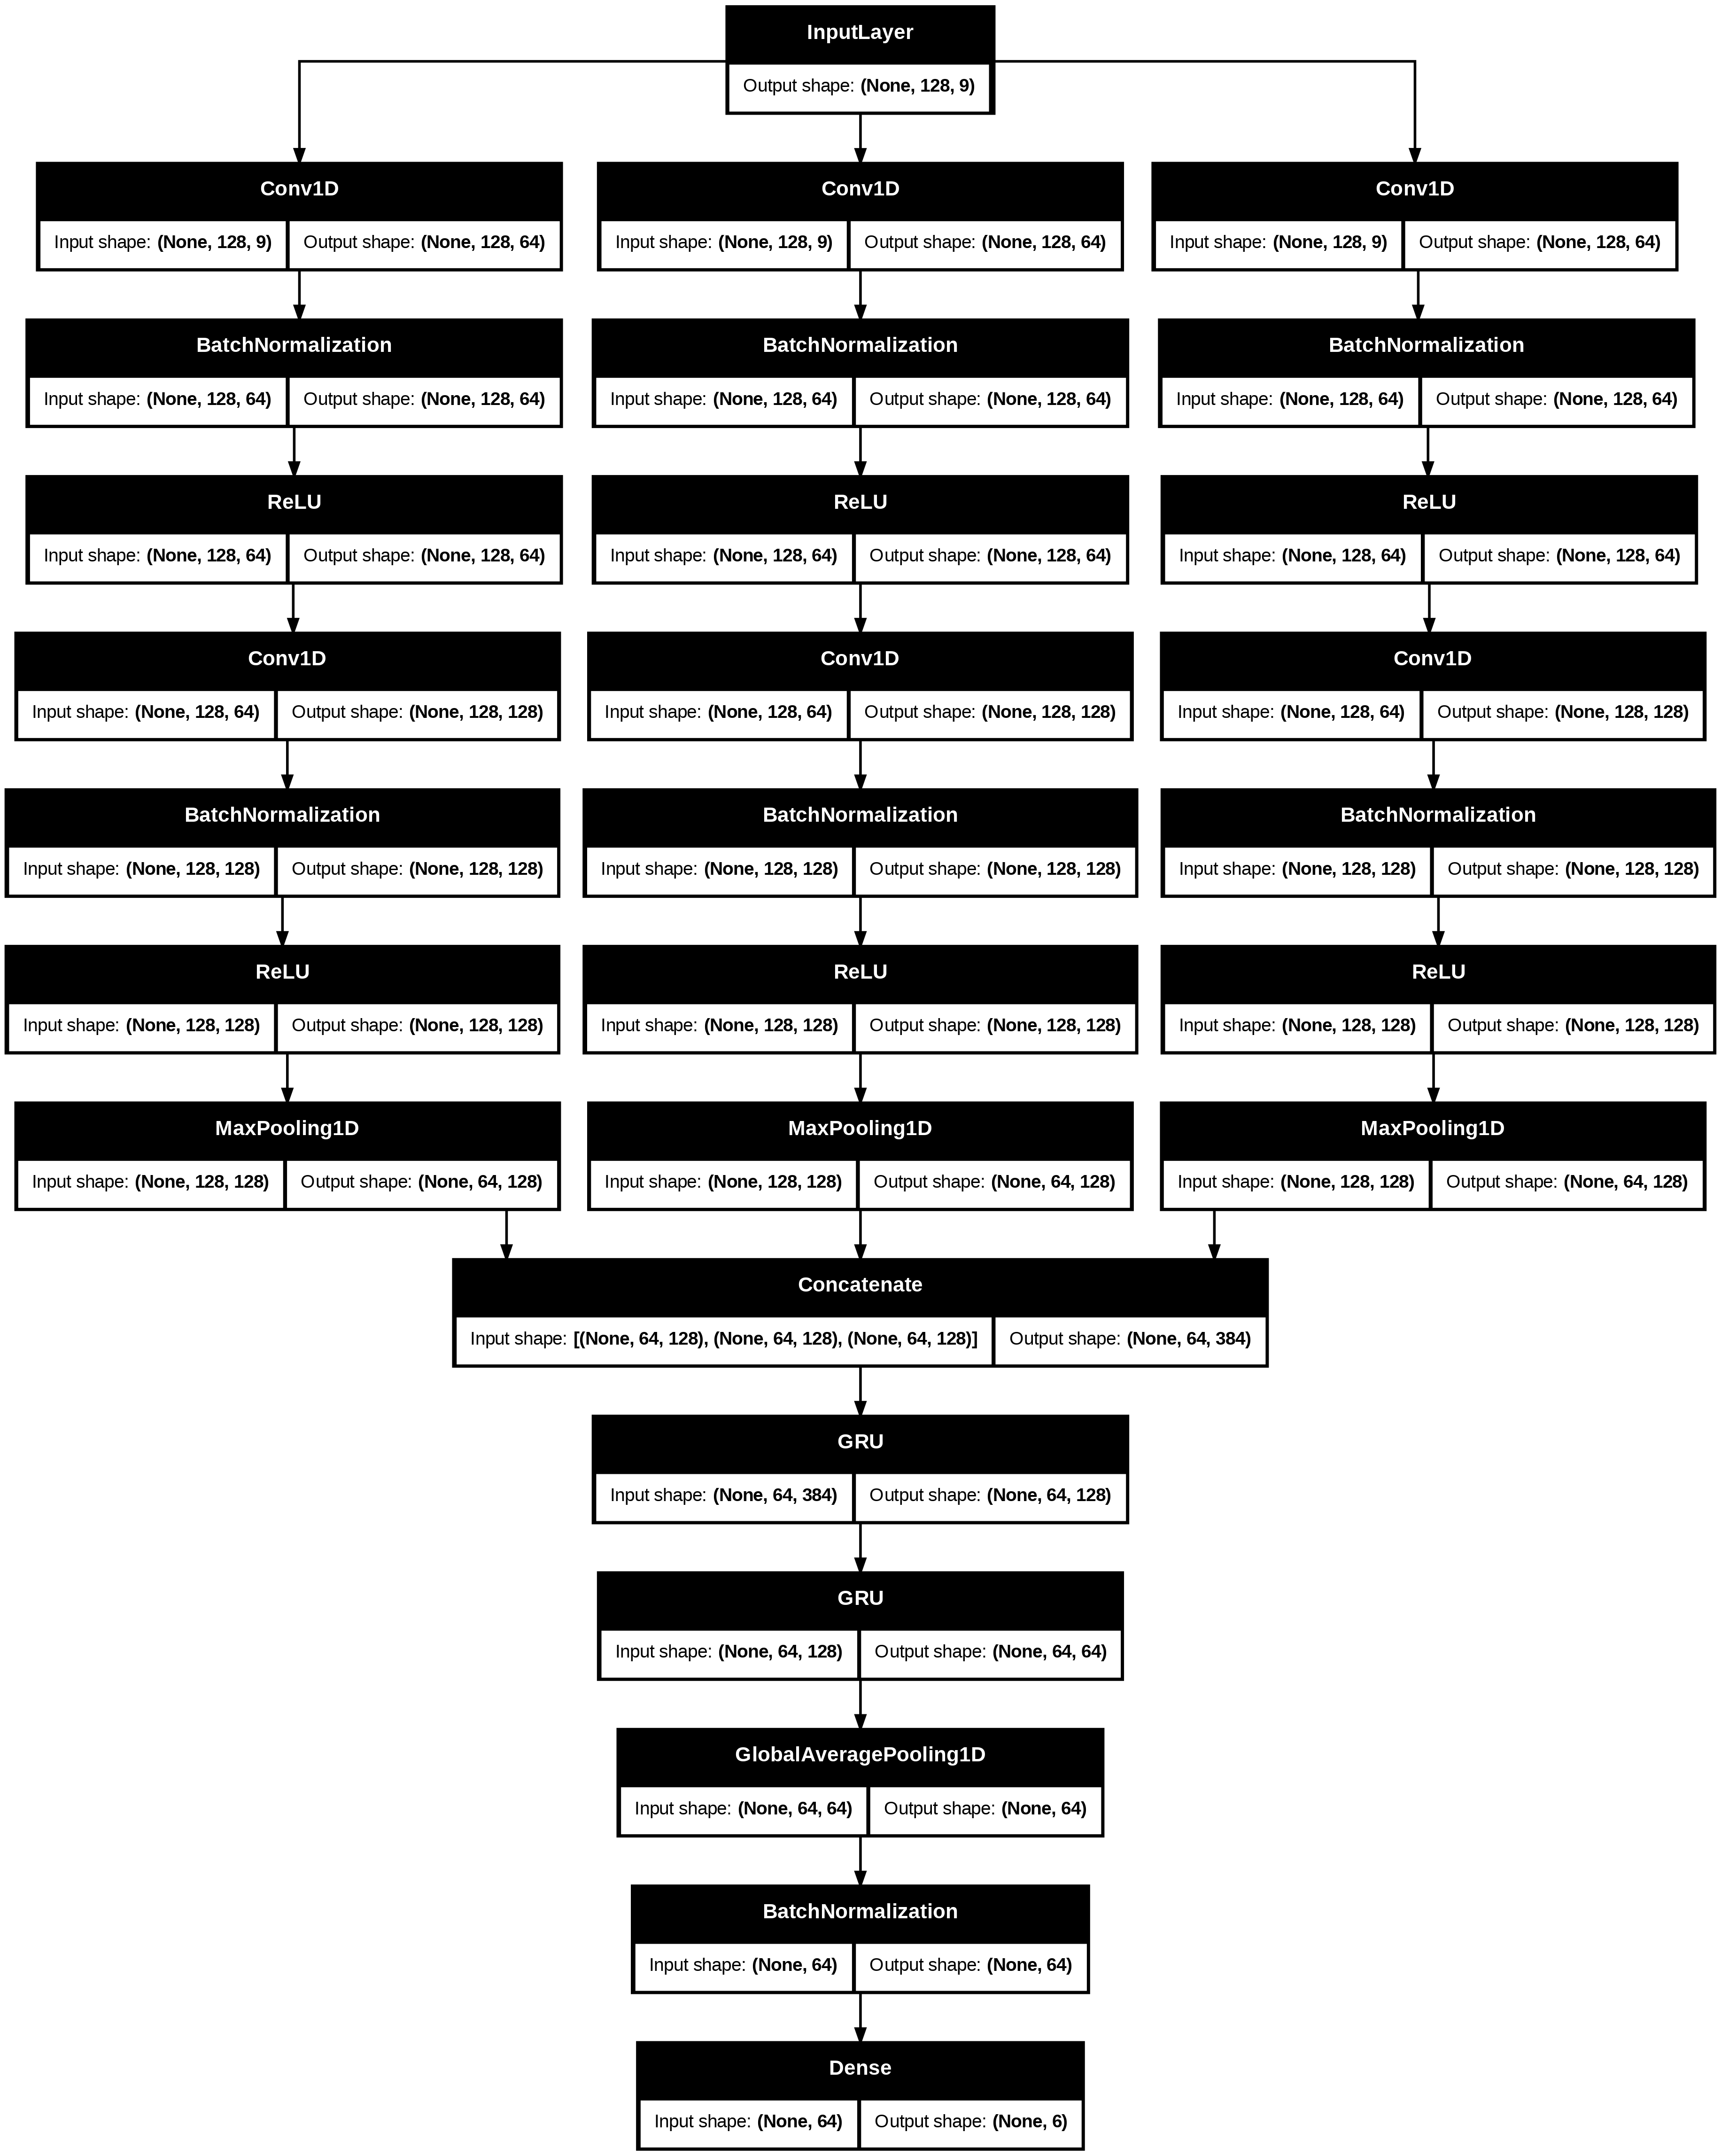

In [66]:
tf.keras.utils.plot_model(model, show_shapes=True)

# callbacks

In [67]:
callbacks = [
            ModelCheckpoint(
                "UCI_HAR_CNN+GRU_best.keras",
                save_best_only=True,
                monitor="val_sparse_categorical_accuracy",
                mode='max',
                verbose=1
            ),
            EarlyStopping(
                monitor="val_sparse_categorical_accuracy",
                patience=20,
                verbose=1,
                mode='max',
                restore_best_weights=True
            ),
            ReduceLROnPlateau(
                monitor='val_loss',
                factor=0.2,
                patience=5,
                min_lr=0.00001,
                verbose=1
            )
        ]

# 모델 학습

In [68]:
history = model.fit(
            X_train, y_train,
            epochs=100,
            batch_size=64,
            validation_split=0.2,
            callbacks=callbacks,
            verbose=1
        )

Epoch 1/100
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.6942 - sparse_categorical_accuracy: 0.8718
Epoch 1: val_sparse_categorical_accuracy improved from None to 0.32019, saving model to UCI_HAR_CNN+GRU_best.keras

Epoch 1: finished saving model to UCI_HAR_CNN+GRU_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - loss: 0.4954 - sparse_categorical_accuracy: 0.9322 - val_loss: 1.8566 - val_sparse_categorical_accuracy: 0.3202 - learning_rate: 0.0010
Epoch 2/100
90/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3750 - sparse_categorical_accuracy: 0.9557
Epoch 2: val_sparse_categorical_accuracy improved from 0.32019 to 0.38545, saving model to UCI_HAR_CNN+GRU_best.keras

Epoch 2: finished saving model to UCI_HAR_CNN+GRU_best.keras
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 0.3738 - sparse_categorical_accuracy: 0.9514 - val_loss: 1.9731 - val_sparse_categorical_accuracy: 0.3855 - learning_rate: 0.0010
Epoch 3/100
91/92 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 0.3182 - sparse_

# 모델 평가

In [69]:
# best 기록 확인
model = tf.keras.models.load_model("UCI_HAR_CNN+GRU_best.keras")

train_loss, train_acc = model.evaluate(X_train, y_train, verbose=0)
print(f"Training accuracy: {train_acc * 100:.2f}%")
print(f"Training loss: {train_loss:.4f}")

test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc * 100:.2f}%")
print(f"Test loss: {test_loss:.4f}")

Training accuracy: 97.48%
Training loss: 0.1013
Test accuracy: 93.35%
Test loss: 0.2699


In [70]:
y_pred_proba = model.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_proba, axis=1)

# 분류 리포트
print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))


Classification Report:
              precision    recall  f1-score   support

           0     0.9958    0.9597    0.9774       496
           1     1.0000    0.9299    0.9637       471
           2     0.8917    1.0000    0.9428       420
           3     0.9104    0.7862    0.8437       491
           4     0.8576    0.9286    0.8917       532
           5     0.9589    1.0000    0.9790       537

    accuracy                         0.9335      2947
   macro avg     0.9357    0.9341    0.9331      2947
weighted avg     0.9357    0.9335    0.9328      2947



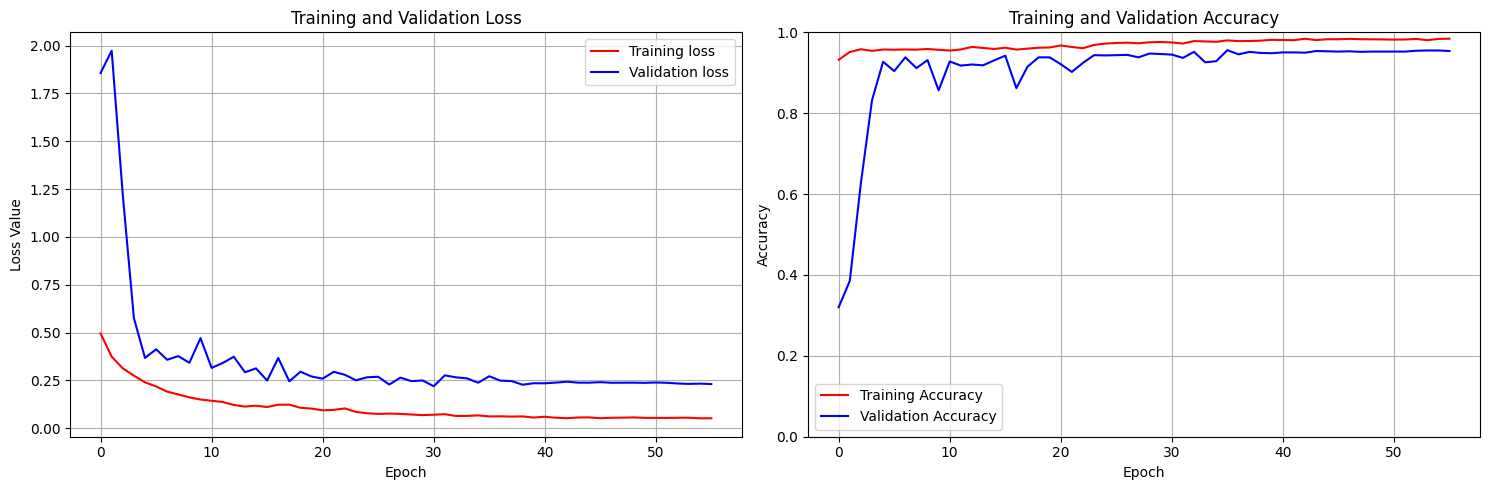

In [71]:
# loss / accuracy 그래프
train_loss = history.history['loss']
train_accuracy = history.history['sparse_categorical_accuracy']
val_loss = history.history['val_loss']
val_accuracy = history.history['val_sparse_categorical_accuracy']

plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
plt.plot(train_loss, 'r', label='Training loss')
plt.plot(val_loss, 'b', label='Validation loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss Value')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.ylim([0.0, 1.0])
plt.plot(train_accuracy, 'r', label='Training Accuracy')
plt.plot(val_accuracy, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

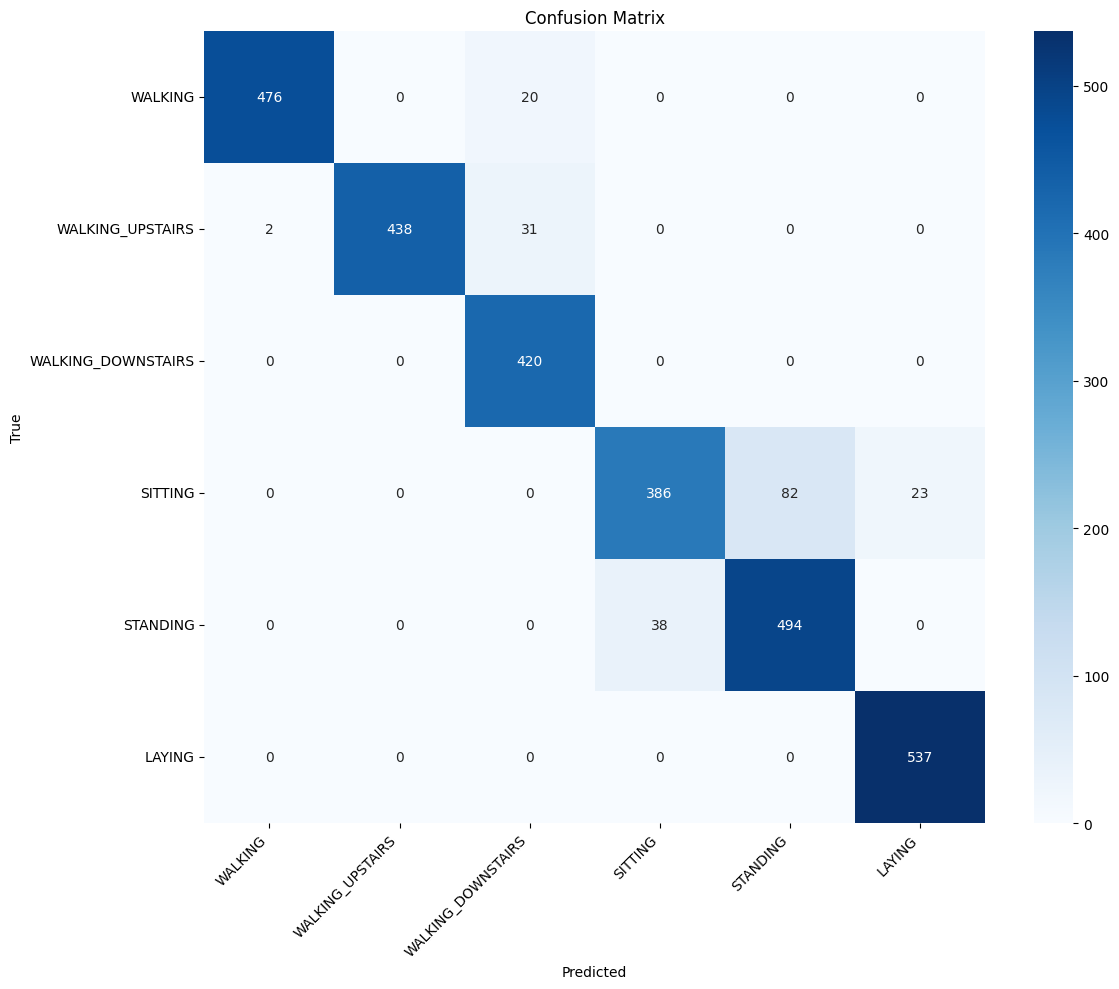

In [72]:
# 혼동행렬(히트맵)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')

n_classes = len(np.unique(y_test))
if n_classes <= len(LABELS):
    plt.gca().set_xticklabels(LABELS[:n_classes], rotation=45, ha='right')
    plt.gca().set_yticklabels(LABELS[:n_classes], rotation=0)

plt.tight_layout()
plt.show()